In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Exercises in STK-IN1050 for week 18

### What this exercise set consists of:

- [A warm-up](#warm-up)
- [Exercise 1:](#exercise-1) Multiple regression
- [Exercise 2:](#exercise-2) Model selection

## A warm-up

A linear regression model is given by

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \sim N(0, \sigma^2),
$$

for $i = 1, \ldots, n$, where $y_i$ is the response variable, $x_i$ is the explanatory variable, and $\varepsilon_i$ is the error term for observation $i$.

**Tasks:**

- List the four assumptions we make for such a model.

- For the model above, we can derive an exact formula for the estimates $\hat{\beta}_0$ and $\hat{\beta}_1$, starting from

    $$
    (\hat{\beta}_0, \hat{\beta}_1) = \arg\min_{\beta_0, \beta_1} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2.
    $$

    Using lecture slides 29, 30 and 31 from lecture 17, write out the steps yourself by hand that lead to the solutions for $\hat{\beta}_0$ and $\hat{\beta}_1$: insert the expression for $\hat{y}_i$, take the partial derivatives with respect to $\beta_0$ and $\beta_1$, and set the two equations equal to zero to find the solutions.

<span style="color: green;">**Possible solution:**</span>

1. **Linearity:** the relationship between the response and the explanatory variable(s) is (approximately) linear.
2. **Independent errors:** the error terms are independent of each other.
3. **Constant variance:** the error terms have the same variance for all values of $x$ (homoscedasticity).
4. **Normality:** the error terms are (approximately) normally distributed.

---

Let $f(\beta_0, \beta_1) = \sum_{i=1}^{n}(y_i - \beta_0 - \beta_1 x_i)^2.$

The partial derivatives are

$$
\frac{\partial f}{\partial \beta_0} = -2\sum_{i=1}^{n}(y_i - \beta_0 - \beta_1 x_i) = -2\,(n\bar{y} - n \beta_0 - n \beta_1 \bar{x}),
$$

$$
\frac{\partial f}{\partial \beta_1} = -2\sum_{i=1}^{n}(y_i - \beta_0 - \beta_1 x_i)\,x_i = -2\left(\sum_{i=1}^{n} x_i y_i - \beta_0 n\bar{x} - \beta_1 \sum_{i=1}^{n} x_i^2\right).
$$

Setting them to zero gives the system

$$
n \beta_0 + n\bar{x}\, \beta_1 = n\bar{y}, \qquad
\beta_0\, n\bar{x} + \beta_1 \sum_{i=1}^{n} x_i^2 = \sum_{i=1}^{n} x_i y_i,
$$

with solution

$$
\boxed{\;\hat{\beta}_1 = \frac{\sum_{i=1}^{n} x_i y_i - n\bar{x}\bar{y}}{\sum_{i=1}^{n} x_i^2 - n\bar{x}^2}
= \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}
= r\,\frac{s_y}{s_x}, \qquad
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}.\;}
$$

In the following exercises, we are to work with a data set on birth weight measurements, including some covariates. The data holds information on a woman's birth, including the previous number of births given, the length of the pregnancy in days, the baby's gender (0: girls, 1: boys), the mother's age and the weight of the baby. The data can be read in using Python as follows (changing some variable ways):

In [22]:
# Load the data and adjust for whitespace separator
data = pd.read_csv('https://www.uio.no/studier/emner/matnat/math/STK1110/data/fodsler.txt', sep=r'\s+', engine='python')
data.rename(columns={'Kjonn': 'gender', 'SvDager': 'pregnancy_days', 'MorsAld': 'mother_age', 'Antfod': 'n_children', 'Fvekt': 'birth_weight'}, inplace=True)
data.head()

,gender,pregnancy_days,mother_age,n_children,birth_weight
0,1,288,24,1,4070
1,1,286,27,0,4220
2,0,276,36,2,3690
3,1,265,31,0,3480
4,1,278,24,1,3970


## Exercise 1

#### Multiple linear regression

#### a)

Display some diagnostics of the data, for instance using some well-known ```pandas``` functions.

<span style="color: green;">**Possible solution:**</span>

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   gender          1000 non-null   int64
 1   pregnancy_days  1000 non-null   int64
 2   mother_age      1000 non-null   int64
 3   n_children      1000 non-null   int64
 4   birth_weight    1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


In [6]:
data.head()

,gender,pregnancy_days,mother_age,n_children,birth_weight
0,1,288,24,1,4070
1,1,286,27,0,4220
2,0,276,36,2,3690
3,1,265,31,0,3480
4,1,278,24,1,3970


In [7]:
data.tail()

,gender,pregnancy_days,mother_age,n_children,birth_weight
995,0,273,25,0,3470
996,0,299,30,2,4010
997,1,267,25,3,4020
998,0,275,27,0,2910
999,0,294,26,1,4260


##### b)

Plot the data, for instance using the [`pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html) function from ```seaborn```. Look closely and comment on the correlations between the covariates you think the model will pick up, especially for ```birth_weight```, which we are to examine closer in exercise c).

<span style="color: green;">**Possible solution:**</span>

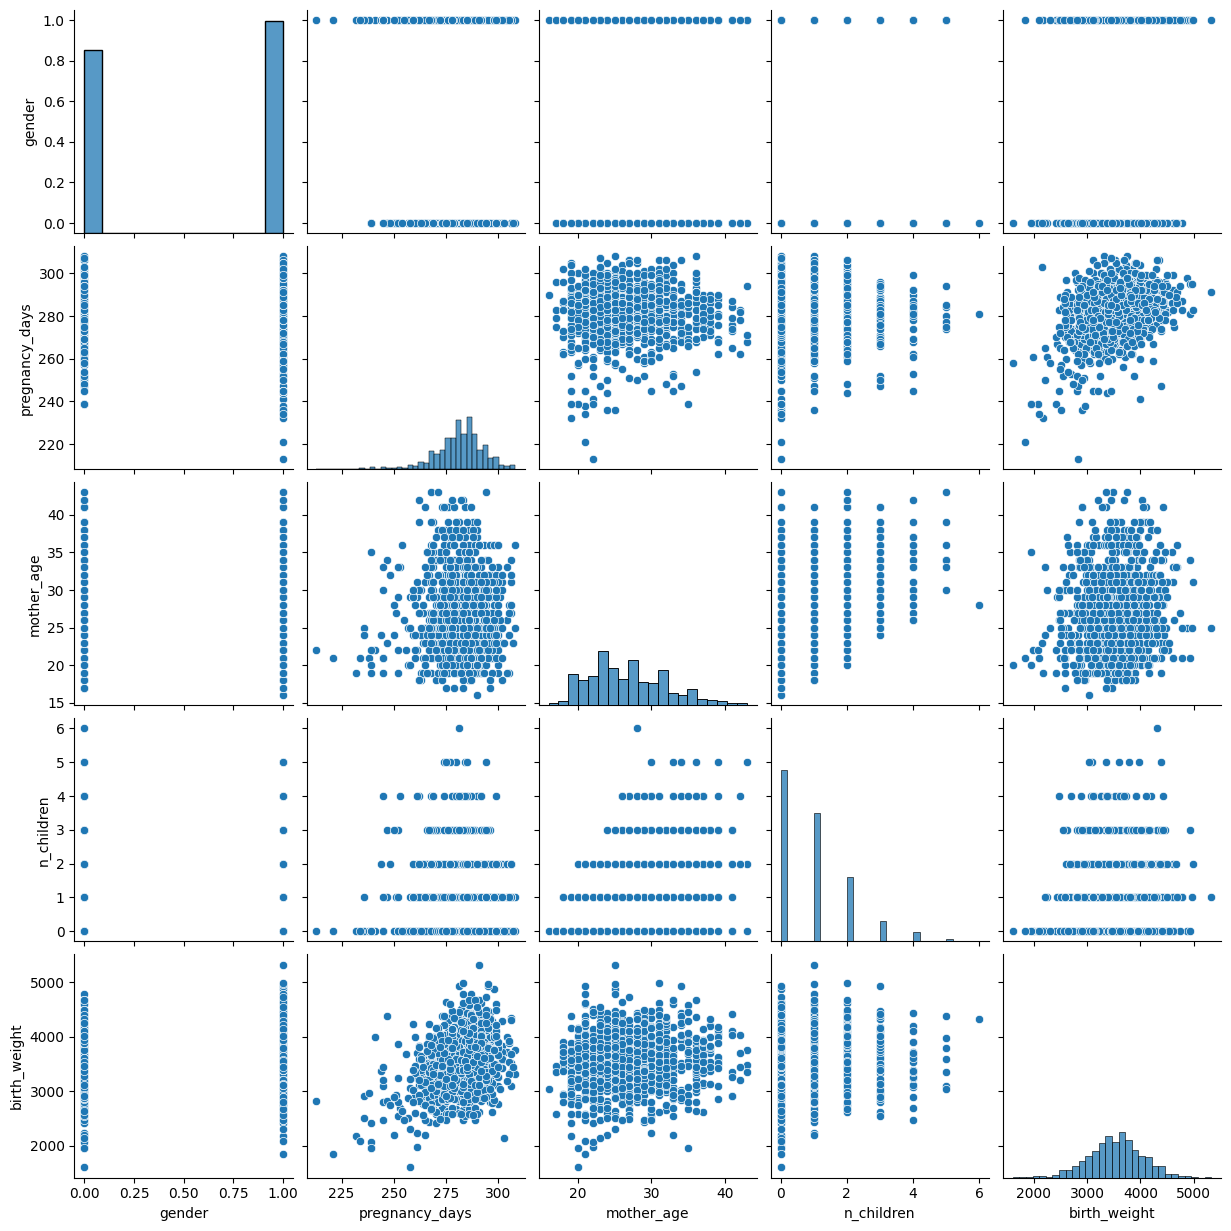

In [8]:
# Pairplot to visualize the dependencies
sns.pairplot(data)
plt.show()

```gender``` shows some marginal effect on ```birth_weight``` in the pairplot, while ```pregnancy_days``` shows a clear positive trend with ```birth_weight```, which we might have guessed.

```n_children``` is also weakly positively associated with ```birth_weight```, although the higher counts (4–6) are very sparse. ```n_children``` is not straightforward to assess either.

#### c)

We are interested in the column ```birth_weight```, and despite what we might have discovered in b), we start with fitting a full model.

- We are here in the scenario of multiple regression. Rewrite a model on the form of
$$
y_i = \beta_0 + \beta_1\,\text{gender}_i + \beta_2\,\text{pregnancy\_days}_i + \beta_3\,\text{mother\_age}_i + \beta_4\,\text{n\_children}_i + \varepsilon_i
$$
on vector form $y = X\beta + \varepsilon$, and specify your $\beta$ vector, $X$ matrix and $\varepsilon$. Also specify their dimensions.

- Program a way to divide the columns of the data into an $X$ matrix and a $y$ vector, and fit the model using [sm.OLS()](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html) from ```statsmodels```, where you consider all your covariates to be numeric.

- Comment on the fit by highlighting the various contributions from the covariates: give a precise interpretation of each coefficient, and what we can say about the covariates' effect on ```birth_weight```.

- Decide on which covariates are significant under the $\alpha = 1\%$ and $\alpha = 5\%$ levels.

<span style="color: green;">**Possible solution:**</span>

On vector form, the model becomes

$$
y = X\beta + \varepsilon,
$$

where, with $n = 1000$ observations and $p = 4$ covariates,

$$
y = \begin{pmatrix} y_1 \\ \vdots \\ y_n \end{pmatrix} \in \mathbb{R}^{n}, \qquad
\beta = (\beta_0, \beta_1, \beta_2, \beta_3, \beta_4)^\top \in \mathbb{R}^{p+1}, \qquad
\varepsilon = (\varepsilon_1, \ldots, \varepsilon_n)^\top \in \mathbb{R}^{n},
$$

and the design matrix is

$$
X = \begin{pmatrix}
1 & \text{gender}_1 & \text{pregnancy\_days}_1 & \text{mother\_age}_1 & \text{n\_children}_1 \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
1 & \text{gender}_n & \text{pregnancy\_days}_n & \text{mother\_age}_n & \text{n\_children}_n

\end{pmatrix} \in \mathbb{R}^{n \times (p+1)}.$$

In [9]:
# Build y
y = data['birth_weight']

# Build X
cols_X = ['pregnancy_days', 'gender', 'mother_age', 'n_children']
X = sm.add_constant(data[cols_X])

# Fit model and drop missing values
model = sm.OLS(y, X, missing="drop").fit()

# Print results and remove footnotes
smry = model.summary()
smry.extra_txt = "" ## Remove footnotes
print(smry)

                            OLS Regression Results                            
Dep. Variable:           birth_weight   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     53.63
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           5.82e-41
Time:                        08:48:54   Log-Likelihood:                -7546.7
No. Observations:                1000   AIC:                         1.510e+04
Df Residuals:                     995   BIC:                         1.513e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -1193.0126    357.482     -3.

Under $\alpha = 5\%$ all four covariates are significant; under $\alpha = 1\%$ ```mother_age``` is not.

Each coefficient $\hat{\beta}_j$ is the estimated change in ```birth_weight``` (in grams) associated with a one-unit increase in covariate $x_j$, holding all other covariates fixed:

- ```mother_age```: a small positive partial effect (a few grams per year), borderline significant.

- ```pregnancy_days```: about $+25$ g per extra day of pregnancy. Strongly significant.

- ```n_children```: each additional previous child is associated with about $+50$–$60$ g, conditional on the others.

- ```gender```: boys (gender = 1) are estimated to be roughly $+100$–$120$ g heavier than girls, on average, conditional on the other covariates.

#### d)

Given the result above, we want to diagnose our model fit. Given the warm-up, program a way to examine the assumptions we made when we used our model for the data. First, you could diagnose and check the model as a whole, and then whether there are problems related to the different covariates.

The code is for you to get a head start, you can uncomment it and start from there.

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(15, 6))
# axes = axes.flatten()
# resid = model.resid
# fitted = model.fittedvalues

# # Histogram of the residuals


# # QQ-plot of the residuals against normal distribution


# # Residuals against fitted values


# plt.tight_layout()
# plt.show()

In [11]:
# # Covariate diagnostics
# fig, axes = plt.subplots(1, 4, figsize=(15, 6))
# axes = axes.flatten()

# # Residuals against individual explanatory variables
# # axes[0].scatter(

# # axes[1].scatter(

# # axes[2].scatter(

# # axes[3].scatter(


# plt.tight_layout()
# plt.show()

<span style="color: green;">**Possible solution:**</span>

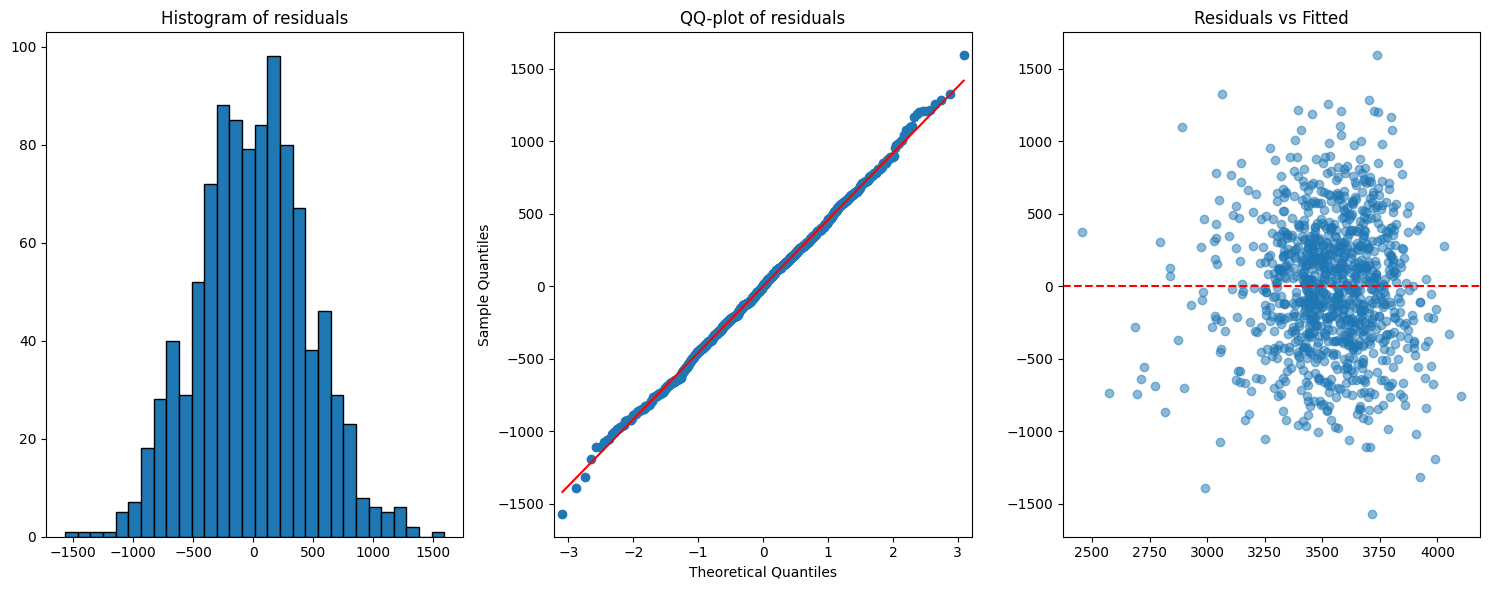

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes = axes.flatten()
resid = model.resid
fitted = model.fittedvalues

# Histogram of the residuals
axes[0].hist(resid, bins=30, edgecolor="black")
axes[0].set_title("Histogram of residuals")

# QQ-plot of the residuals against normal distribution
sm.qqplot(resid, line='s', ax=axes[1])
axes[1].set_title("QQ-plot of residuals")

# Residuals against fitted values
axes[2].scatter(fitted, resid, alpha=0.5)
axes[2].set_title("Residuals vs Fitted")
axes[2].axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

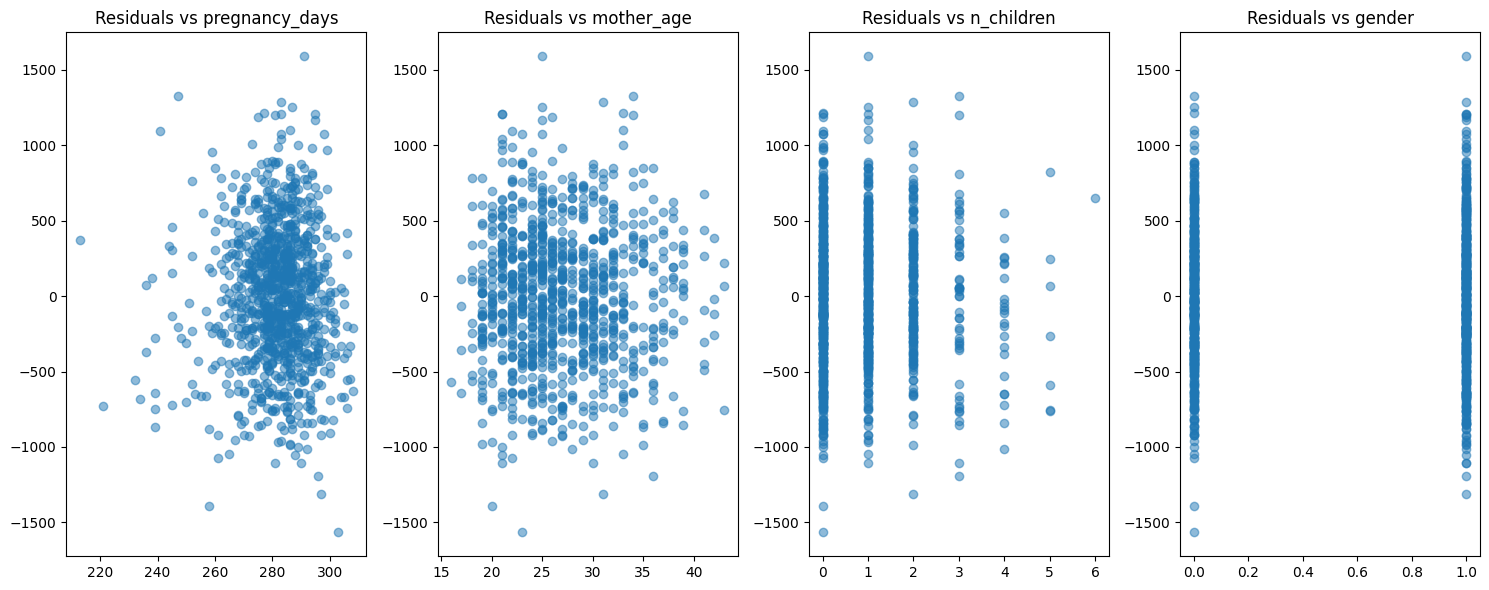

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 6))
axes = axes.flatten()

# Residuals against individual explanatory variables
axes[0].scatter(data.loc[model.resid.index, "pregnancy_days"], resid, alpha=0.5)
axes[0].set_title("Residuals vs pregnancy_days")

axes[1].scatter(data.loc[model.resid.index, "mother_age"], resid, alpha=0.5)
axes[1].set_title("Residuals vs mother_age")

axes[2].scatter(data.loc[model.resid.index, "n_children"], resid, alpha=0.5)
axes[2].set_title("Residuals vs n_children")

axes[3].scatter(data.loc[model.resid.index, "gender"], resid, alpha=0.5)
axes[3].set_title("Residuals vs gender")

plt.tight_layout()
plt.show()

We are in a situation where the model looks reasonably well-specified:

- The per-covariate residual plots also show no systematic pattern. ```n_children``` is the most suspicious one, as residuals are concentrated at a few discrete values and become very sparse for high counts, as commented on above.

- The histogram of the residuals is roughly symmetric and normal-shaped, and the QQ-plot lies close to the diagonal — the normality assumption looks acceptable, with only some mild deviations at the tails.

- The residuals-vs-fitted plot shows a fairly even "cloud" around zero, with no obvious trend or fan shape — linearity and constant variance look fine.

#### e)

Describe with your own words what an obvious model misspecification would look like for each of the assumptions made in the plots made above.

<span style="color: green;">**Possible solution:**</span>

- **Linearity:** in the residuals-vs-fitted plot (or residuals against any individual covariate), a clear systematic pattern such as a curve, a U-shape, or a tilt would indicate that the linear form is wrong and that the relationship is non-linear.
- **Independent errors:** structure in the residuals would indicate dependence — for instance, residuals clustering together for observations sharing a group.
- **Constant variance (homoscedasticity):** a fan or funnel shape in residuals-vs-fitted, where the spread of residuals grows (or shrinks) with the fitted value, indicates non-constant variance.
- **Normality:** in the histogram, strong skewness or heavy tails; in the QQ-plot, systematic departure from the diagonal would indicate non-normal errors.

#### f)

Before moving into model selection, and as a bridge to the next exercise, we want to highlight one specific thing we have not emphasised in our modelling. Specifically, it relates to our two categorical variables. 

```gender``` is already dummy-encoded, and could be considered fine already, but ```n_children``` is here treated as a linear variable.

What can be done differently when we model this, especially given the fact that there are fewer and fewer cases in our data for an increasing ```n_children```? Hint: think about bins. 

<span style="color: green;">**Possible solution:**</span>

Treating ```n_children``` as a linear numeric variable forces the effect of going from 0 to 1 child to be exactly the same as going from 5 to 6 children, which might be a wrong assumption, especially since we have few observations there.

A more flexible approach is to treat ```n_children``` as a categorical variable and dummy-encode it, so each level gets its own coefficient relative to the reference category. We could bin the sparse upper levels together into a single "$n+$" category — for instance collapsing 4, 5 and 6 into a "3+" group.

## Exercise 2)

#### Model selection

#### a)

Program a way to fit the alternative model for a respecified ```n_children``` covariate from 1f). Refer to your exploratory data analysis to conclude on from which ```n_children``` value you want to bin the covariates, i.e. create a "$n+$" category for some $n$. The text book in the course could provide you with some help here.

<span style="color: green;">**Possible solution:**</span>

In [ ]:
alternative_data = data.copy()
alternative_data["n_children"] = alternative_data["n_children"].apply(
    lambda x: "3+" if x > 3 else str(int(x))
)

# Build y and X (dummy-encode n_children, reference level "0": setting that as the base level)
alternative_y = alternative_data["birth_weight"]
alternative_X = pd.get_dummies(
    alternative_data[["pregnancy_days", "gender", "mother_age", "n_children"]],
    columns=["n_children"], drop_first=True, dtype=int,
)
alternative_X = sm.add_constant(alternative_X)

# Fit model and drop missing values
model = sm.OLS(alternative_y, alternative_X, missing="drop").fit()

#### b)

- Print the model summary of your new model and use [stripplot()](https://seaborn.pydata.org/generated/seaborn.stripplot.html) from ```seaborn``` to plot the new diagnostics of your new ```n_children```.

- Comment on both.

- What is the interpretation of each ```n_children``` bin now? Is it relative to something?

<span style="color: green;">**Possible solution:**</span>

                            OLS Regression Results                            
Dep. Variable:           birth_weight   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     36.72
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           2.59e-40
Time:                        09:36:25   Log-Likelihood:                -7544.1
No. Observations:                1000   AIC:                         1.510e+04
Df Residuals:                     993   BIC:                         1.514e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -1120.7857    358.356     -3.

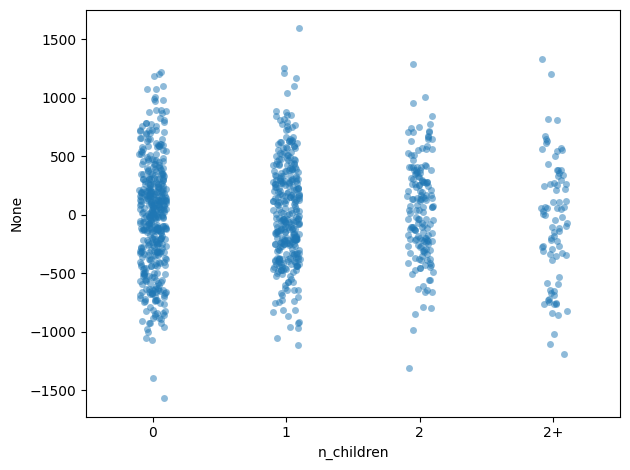

In [ ]:
# Print results and remove footnotes
smry = model.summary()
smry.extra_txt = "" ## Remove footnotes
print(smry)

# Plot new residuals
sns.stripplot(x=alternative_data["n_children"], y=resid,
              order=["0", "1", "2", "3", "3+"], alpha=0.5)
plt.tight_layout()
plt.show()

We now get one coefficient per bin (`n_children_1`, `n_children_2`, `n_children_3`, `n_children_3+`), each measuring the average ```birth_weight``` in that bin compared to the reference level `n_children = 0`. The `3+` bin has a much wider confidence interval since it collects the few observations with many previous children.

Interestingly, the coefficients increase up to a point and then decrease again. It suggests that birth weight rises with the first few children and then drops off. So a model with a squared ```n_children``` term might capture the pattern better than the plain linear one, but this is outside of our scope here.

The stripplot shows residuals spread roughly symmetrically around zero in every bin, with no clear trend in the spread, so the constant-variance assumption still looks fine as earlier. Given this, we might argue that the simpler model was fine, especially since some of the bins become insignificant.

It should also be noted that, for a new model, one should in general re-assess all aspects for a new fit.

#### c)

We now have two models to compare. One method we have talked about in class is the $R^2$.

- Define SST, SSR and SSE, describe them in your own words, and compare the two models' output $R^2$ value. The lecture slides might help you here.

- Note your two different degrees of freedom for the two models. Why is this? Related to this, explain what the adjusted $R^2$ accounts for that the $R^2$ does not, when outputting a number we can use to assess model fit.

- Given the values you observe, how would you decide based on the two metrics here? There might not be a definite and clear answer.

<span style="color: green;">**Possible solution:**</span>

- **SST, SSR, SSE.** With $\bar{y}$ the mean of the response and $\hat{y}_i$ the fitted values,

    $$
    \text{SST} = \sum_{i=1}^{n}(y_i - \bar{y})^2, \qquad
    \text{SSR} = \sum_{i=1}^{n}(\hat{y}_i - \bar{y})^2, \qquad
    \text{SSE} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2,
    $$

    with $\text{SST} = \text{SSR} + \text{SSE}$. SST is the total variability in $y$, SSR is the part the model explains, SSE is the leftover. Then $R^2 = \text{SSR}/\text{SST}$ is the share of variability captured by the model. The two models give almost identical $R^2$, with the categorical model very slightly higher.

- The residual dof is $n - p - 1$. The linear model uses $p = 4$, the categorical model uses $p = 7$ (three extra dummies for `n_children`), so it spends three more dof. Adjusted $R^2$,

    $$
    R^2_{\text{adj}} = 1 - (1 - R^2)\,\frac{n - 1}{n - p - 1},
    $$

    penalises extra parameters: $R^2$ can only go up when adding a covariate, while $R^2_{\text{adj}}$ goes down if the gain in fit does not justify the extra parameter.

- The gain in $R^2$ is tiny while the categorical model spends three extra parameters. It is a close call.

#### d)

We have also talked about other model selection criteria.

Both of our models obviously receive for instance valid p-values under an F-test.

For $AIC$ and $BIC$, the picture is less clear.

- Note down the $AIC$ and $BIC$ formulas.
- Summarise for yourself what each term describes in respectively $AIC$ and $BIC$. How do these terms balance each other?
- What is then the difference between $AIC$ and $BIC$?
- Decide on which model you prefer based on $AIC$ and $BIC$. (This could be a close call).

<span style="color: green;">**Possible solution:**</span>

- With $k$ the number of estimated parameters and $\hat{L}$ the maximised likelihood,

    $$
    AIC = 2k - 2\ln\hat{L}, \qquad BIC = k\ln n - 2\ln\hat{L}.
    $$

- The $-2\ln\hat{L}$ term measures lack of fit (smaller is better). The $2k$ (AIC) or $k\ln n$ (BIC) term is a penalty for model complexity. The two balance each other: adding a parameter improves the fit but increases the penalty.

- AIC penalises each extra parameter by $2$, BIC by $\ln n$. For our $n = 1000$, $\ln n \approx 6.9 \gg 2$, so BIC is stricter about extra parameters than AIC.

- The categorical model has three more parameters but only a marginally better log-likelihood, so AIC is roughly comparable between the two and BIC slightly prefers the simpler model. It is still a close call.

#### e)

It has indeed been difficult to observe any large differences in our two models, obviously because they are very similar.

- Regardless, finally decide on which one you would prefer given what you have already noted in c) and d).

- Does the change we did to ```n_children``` add much value? Why/why not? Here, you might get some help from looking at the coefficient parts of the model summaries.

<span style="color: green;">**Possible solution:**</span>

Given that $R^2_{\text{adj}}$, AIC and BIC are close to a tie, and given what we commented on in 2b), the first and simplest model might be said to be fair enough: it is simpler and loses essentially no explanatory power.

The re-encoding did not add much value here: it confirmed that the linear assumption for `n_children` is reasonable on this data. It did suggest and uncover a potential non-linear pattern that we could have assessed, but as it was not able to handle it better than the original model, we did not find the categorical model to be a better fit through an overall assessement.

#### f)

Reflect for yourself what this exercise exemplified in terms of how models and model selection might not be straight-forward to interpret nor decide between. In your own words, what could be considered a good model, for instance for the data we have seen here, and which aspects does a good model balance? 

<span style="color: green;">**Possible solution:**</span>

This exercise was meant to illustrate that model selection is not always straightforward: two reasonable models can give very similar fits, and different criteria ($R^2$, $R^2_{\text{adj}}$, AIC, BIC) can point in slightly different directions.

A good model balances roughly the interpretability and predictive power. It should explain a meaningful share of the variation in the response when we test in-sample as we do here (we do not split into a test and training set) and it should be "parsimonious": it should not use more parameters than the data can support.